Baseline CNN

12 mars : suite à la proposition de Marine, je propose de tester un modèle basique de CNN dont l'écriture correspond au cours.

1) Imports

In [2]:
import tensorflow as tf
from tensorflow.keras import Sequential, Input, layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

I0000 00:00:1773421459.009399  159031 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773421459.018379  159031 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773421459.990814  159031 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773421464.748252  159031 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

2) Création du modèle

Hypothèses :
- Objectif du modèle : établir une performance de référence avec une architecture simple.
- Données d'entrée : des images couleurs --> Input(shape=(224, 224, 3)) :
    Dimensions : Des images de 224 pixels de large sur 224 pixels de haut.
    Couleurs : Le chiffre 3 correspond aux canaux RVB (Rouge, Vert, Bleu).
    Volume : Les données arrivent par "paquets" (Batchs), généralement de 32 images à la fois.
- Fonctionnement du modèle : Le modèle fonctionne comme un entonnoir qui transforme des pixels en concepts abstraits :
   1) Les Blocs de Convolution (Extraction de traits)
    Conv2D : Imagine une petite loupe qui scanne l'image. Au début (Bloc 1), elle repère des choses simples : des lignes, des bords de cadres, des taches de couleur. Au Bloc 2, elle commence à reconnaître des formes (un visage, un coup de pinceau spécifique).

    MaxPooling2D : Cette couche divise par deux la taille de l'image. Elle ne garde que l'information la plus "forte" de chaque zone. Cela permet au modèle d'être plus rapide et de ne pas se perdre dans des détails inutiles.

    2) Le Passage en 1D (Flatten)
    L'image est encore une grille (un carré). Pour que les neurones de la fin puissent voter, on "aplatit" cette grille en une seule longue ligne de chiffres.

    3)La Décision (Dense & Dropout)
    Dense(128) : C'est ici que l'intelligence se crée. Ces neurones croisent toutes les informations extraites précédemment pour se dire : "Si j'ai beaucoup de bleu et des traits fins, c'est peut-être de l'Impressionnisme".

    Dropout(0.5) : C'est ton filet de sécurité. Pendant l'entraînement, il "éteint" la moitié des neurones au hasard. Ça force le modèle à ne pas devenir "fainéant" et à apprendre plusieurs chemins pour reconnaître un style.

    Dense(8, activation='softmax') : La couche finale. Elle sort 8 chiffres qui s'additionnent pour faire 100%. Par exemple : 0.80 pour Cubisme, 0.10 pour Réalisme, etc. Le modèle choisit le score le plus haut.

- Sortie : le courant artistique résultant de l'image d'entrée

In [24]:
model = Sequential()
model.add(Input(shape=(224, 224, 3)))

# Bloc 1 : on extrait les traits
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloc 2 : on passe en 1D
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Couche de classification
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax')) # 5 = nombre de courants artistiques

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,682 (91.20 MB)

 Trainable params: 23,908,682 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

2) Création des échantillonages d'apprentissage

In [11]:
# 1. On définit les chemins vers les dossiers : ils sont dans data/out/
path_train = "../data/out/train"
path_val = "../data/out/val"

# 2. Création du dataset d'entraînement
train_ds = tf.keras.utils.image_dataset_from_directory(
path_train,
label_mode='categorical',
batch_size=32,
image_size=(224, 224)
)

# 3. Création du dataset de validation
val_ds = tf.keras.utils.image_dataset_from_directory(
path_val,
label_mode='categorical',
batch_size=32,
image_size=(224, 224)
)

Found 48474 files belonging to 10 classes.
Found 6057 files belonging to 10 classes.


3) Les courbes d'apprentissage

Objectif : voir si le modèle stagne, s'il progresse ou s'il fait de l'overfitting.

Epoch 1/10
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 1074s 707ms/step - accuracy: 0.2132 - loss: 9.0939 - val_accuracy: 0.2194 - val_loss: 2.1605
Epoch 2/10
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 1077s 711ms/step - accuracy: 0.2352 - loss: 2.1456 - val_accuracy: 0.2254 - val_loss: 2.1640
Epoch 3/10
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 1060s 699ms/step - accuracy: 0.2595 - loss: 2.0949 - val_accuracy: 0.2278 - val_loss: 2.1627
Epoch 4/10
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 1059s 699ms/step - accuracy: 0.2973 - loss: 2.0064 - val_accuracy: 0.2305 - val_loss: 2.1818
Epoch 5/10
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 1061s 700ms/step - accuracy: 0.3567 - loss: 1.8661 - val_accuracy: 0.2280 - val_loss: 2.2531
Epoch 6/10
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 1004s 663ms/step - accuracy: 0.4149 - loss: 1.7159 - val_accuracy: 0.2252 - val_loss: 2.3555
Epoch 7/10
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 998s 659ms/step - accuracy: 0.4557 - loss: 1.6308 - val_accuracy: 0.2199 - val_loss: 2.5492
Epoch 8/10
1515/1515 ━━━━━━━━━━━━━━━━━━━━ 1002s 661ms/st

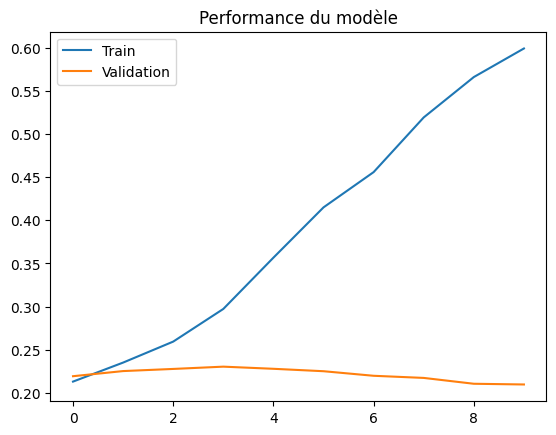

In [12]:
# on compile et on fit sur le train

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)
print(history)

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Performance du modèle')
plt.legend()
plt.show()

4) Matrice de confusion

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

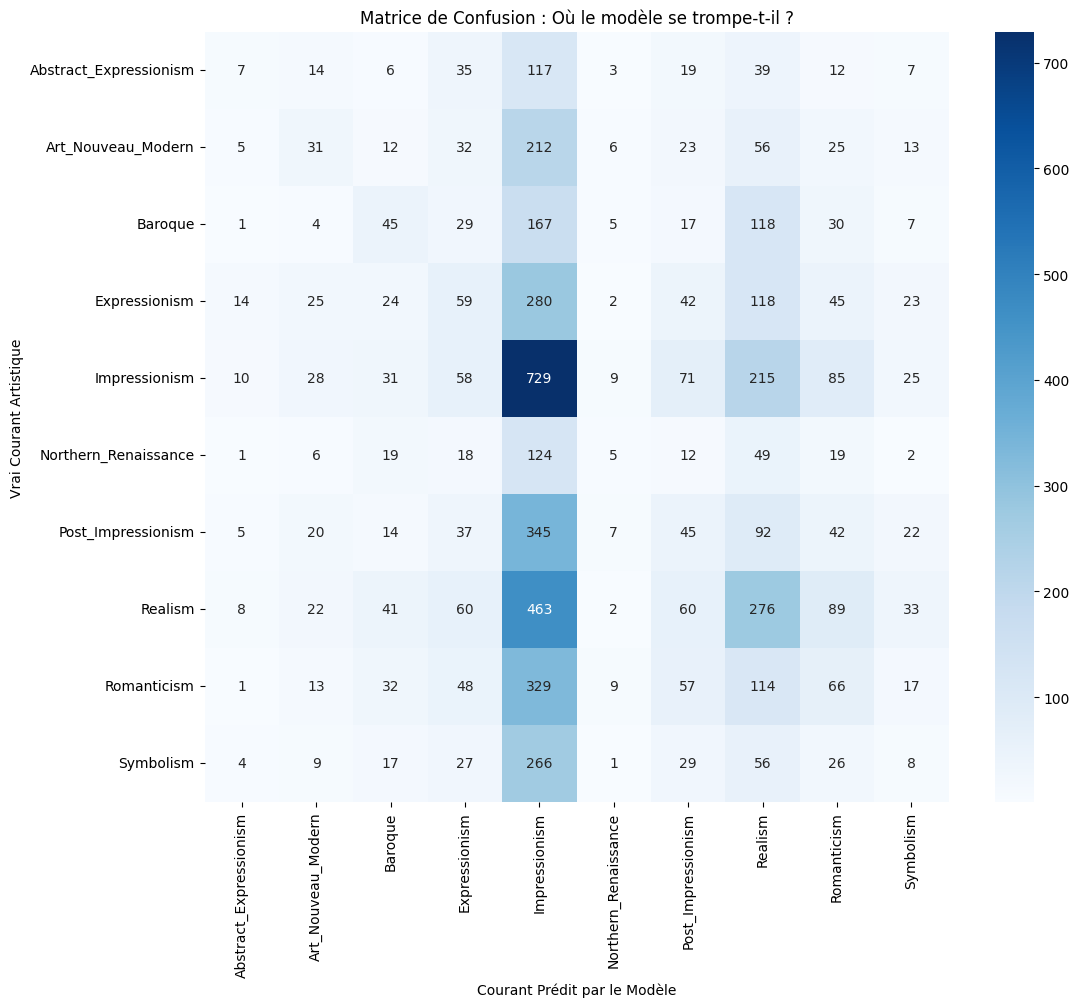

In [14]:
# 1. On récupère les vraies étiquettes et les prédictions du modèle
y_true = []
y_pred = []

# On parcourt le dataset de validation
for x, y in val_ds:
    predictions = model.predict(x)
    y_true.extend(np.argmax(y, axis=1)) # La vraie classe
    y_pred.extend(np.argmax(predictions, axis=1)) # La classe devinée

# 2. Création de la matrice
cm = confusion_matrix(y_true, y_pred)
class_names = val_ds.class_names # Récupère tes noms de dossiers (Baroque, etc.)

# 3. Affichage graphique
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de Confusion : Où le modèle se trompe-t-il ?')
plt.ylabel('Vrai Courant Artistique')
plt.xlabel('Courant Prédit par le Modèle')
plt.show()

In [15]:
import os

# Indique ici le chemin vers ton dossier train
# D'après tes messages précédents, c'est :
path_train = "../data/out/train"

print("--- COMPTAGE DES OEUVRES PAR CLASSE ---")

for dossier in sorted(os.listdir(path_train)):
    chemin_complet = os.path.join(path_train, dossier)
    if os.path.isdir(chemin_complet):
        nb_images = len(os.listdir(chemin_complet))
        print(f"{dossier} : {nb_images} images")

--- COMPTAGE DES OEUVRES PAR CLASSE ---
Abstract_Expressionism : 2075 images
Art_Nouveau_Modern : 3301 images
Baroque : 3376 images
Expressionism : 5064 images
Impressionism : 10135 images
Northern_Renaissance : 2041 images
Post_Impressionism : 5039 images
Realism : 8427 images
Romanticism : 5491 images
Symbolism : 3525 images


Comment lire ce graphique (Pour ta présentation)
La Diagonale (du haut-gauche au bas-droite) : Ce sont les victoires ! Plus les chiffres sont élevés ici, plus ton modèle est bon.

Les cases hors-diagonale : Ce sont les erreurs.

Exemple : Si tu as un "15" à l'intersection de la ligne "Impressionnisme" et de la colonne "Post-Impressionnisme", tu peux dire à ton groupe : "Le modèle a du mal à distinguer ces deux-là car les techniques de pinceau sont proches".

Les cases vides : Si une colonne est vide, c'est que le modèle n'a jamais osé prédire ce courant artistique. Il est peut-être "biaisé".

5) on homogéneise les catégories en nombre d'image

In [23]:
path_train = "../data/out/train"
fnames = []
labels = []
class_names = sorted(os.listdir(path_train))

# 1. On liste manuellement les fichiers pour limiter à 2600
for label in os.listdir(path_train):
    subfolder = os.path.join(path_train, label)
    if os.path.isdir(subfolder):
        images = os.listdir(subfolder)[:2075] # ON BLOQUE À 2075 ICI
        for img in images:
            fnames.append(os.path.join(subfolder, img))
            labels.append(label)

# 2. On crée le nouveau train_ds à partir de cette liste
# (C'est un peu plus technique mais ça marche à tous les coups)
train_ds = tf.data.Dataset.from_tensor_slices((fnames, labels))

def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    img = img/255
    label_id = tf.argmax(label == class_names)
    label_onehot = tf.one_hot(label_id, depth=10)
    return img, label_onehot

# On transforme les noms en vraies images
# Note : il faudra aussi transformer tes labels en chiffres (one-hot)
train_ds = train_ds.map(process_path).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 1. On définit le garde-fou (Early Stopping)
callback_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=2, # S'arrête si ça ne s'améliore plus pendant 2 époques**
    restore_best_weights=True # Garde le meilleur modèle, pas le dernier**
)

# 2. On relance l'entraînement
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[callback_stop]
)

Epoch 1/10


648/648 ━━━━━━━━━━━━━━━━━━━━ 495s 761ms/step - accuracy: 0.5563 - loss: 4.8450 - val_accuracy: 0.1043 - val_loss: 5637.9048
Epoch 2/10
648/648 ━━━━━━━━━━━━━━━━━━━━ 494s 762ms/step - accuracy: 0.2703 - loss: 2.7034 - val_accuracy: 0.1027 - val_loss: 217.6094
Epoch 3/10
648/648 ━━━━━━━━━━━━━━━━━━━━ 488s 752ms/step - accuracy: 0.2991 - loss: 3.5013 - val_accuracy: 0.0442 - val_loss: 93.1285
Epoch 4/10
648/648 ━━━━━━━━━━━━━━━━━━━━ 486s 750ms/step - accuracy: 0.2754 - loss: 2.4508 - val_accuracy: 0.0809 - val_loss: 159.8185
Epoch 5/10
648/648 ━━━━━━━━━━━━━━━━━━━━ 521s 804ms/step - accuracy: 0.3208 - loss: 2.8481 - val_accuracy: 0.0717 - val_loss: 59.3753
Epoch 6/10
648/648 ━━━━━━━━━━━━━━━━━━━━ 509s 784ms/step - accuracy: 0.2346 - loss: 2.2512 - val_accuracy: 0.0702 - val_loss: 82.6957
Epoch 7/10
648/648 ━━━━━━━━━━━━━━━━━━━━ 497s 766ms/step - accuracy: 0.2991 - loss: 3.1835 - val_accuracy: 0.0768 - val_loss: 56.2750
Epoch 8/10
648/648 ━━━━━━━━━━━━━━━━━━━━ 509s 786ms/step - accuracy: 0.2790 -

In [3]:
plt.plot(history2.history2['accuracy'], label='Train')
plt.plot(history2.history2['val_accuracy'], label='Validation')
plt.title('Performance du modèle')
plt.legend()
plt.show()

NameError: name 'history2' is not defined